# NLP Project 5: Social Media Comment Analysis

**Problem Statement**

A company regularly launches products and marketing campaigns on social media platforms
where customers share comments, opinions, and reactions. Understanding public sentiment
and customer perception is important for brand reputation and business growth. Since
social media generates huge volumes of unstructured text data, this project uses NLP
techniques to analyze customer comments, identify trending topics, and understand
overall public opinion about the company's products and services.

**Tasks**
1. Collect social media comments
2. Clean and preprocess text
3. Perform sentiment analysis
4. Identify trending topics
5. Visualize public opinion

> This notebook uses only `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn`.
> Sentiment analysis is implemented using a **custom lexicon-based scorer** (similar in
> spirit to VADER), and trending topics are found via **hashtag/word frequency counts**
> and **LDA topic modeling** — so the whole pipeline runs with no external API keys or
> pretrained downloads required.

## 0. Imports & Setup

In [1]:
import re
import random
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
random.seed(42)
np.random.seed(42)

## Step 1: Collect Social Media Comments

In a real-world setting this data would come live from the Twitter/X API, Instagram
Graph API, YouTube Data API, or a social-listening tool export. Since that needs
credentials/internet access, we simulate a realistic export (comment text, platform,
timestamp, likes, hashtags) of customer reactions to a product launch and marketing
campaign — the same shape of data a real export would have. To use real data, just
replace `generate_social_media_dataset()` with `pd.read_csv('your_export.csv')`.

In [2]:
def generate_social_media_dataset(n=250):
    platforms = ["Twitter", "Instagram", "Facebook", "YouTube"]

    positive_templates = [
        "I absolutely love the new {product}, best {category} I've bought this year! #amazing",
        "The {product} exceeded my expectations, great {aspect} and super fast delivery.",
        "Huge fan of this {campaign} campaign, so creative and well executed! #love",
        "{product} works perfectly, the {aspect} is fantastic. Highly recommend to everyone.",
        "Customer support helped me instantly, great {aspect}! Will buy again #happycustomer",
        "This is the best {category} in the market right now, worth every penny.",
        "Loving the new update, the {aspect} improvements are exactly what we needed!",
        "Amazing {campaign}! You guys really understand your customers. #brandlove",
        "The {product} quality is outstanding, super happy with this purchase.",
        "Five stars! The {aspect} and packaging were both excellent.",
    ]

    negative_templates = [
        "Really disappointed with the {product}, the {aspect} is terrible. #fail",
        "Worst {category} experience ever, {aspect} broke within a week.",
        "The {campaign} campaign feels fake and misleading, not happy at all.",
        "Customer service was rude and unhelpful about my {product} issue. #angry",
        "Waste of money, the {aspect} does not work as advertised.",
        "This {product} is overpriced for such poor {aspect} quality.",
        "I regret buying this {category}, delivery was late and item was damaged.",
        "Terrible experience with the {campaign}, feels like a scam. #disappointed",
        "The app keeps crashing after the update, very frustrating {aspect}.",
        "Poor build quality, {aspect} stopped working after two days. Refund please.",
    ]

    neutral_templates = [
        "Just received my {product}, will share a review after using it for a while.",
        "Does anyone know if the {product} comes in other colors?",
        "Saw the ad for the new {campaign}, planning to check it out this weekend.",
        "The {product} looks okay, still deciding if the {aspect} is worth the price.",
        "Can someone confirm the return policy for the {category}?",
        "Watched the {campaign} launch event, some interesting features shown.",
        "Comparing this {product} with the older version before deciding to upgrade.",
        "What's the warranty period for the {product}?",
        "Picked up the {category} today, first impressions coming soon.",
        "Is the {campaign} discount available in all regions?",
    ]

    products = ["SmartWatch X200", "EcoBottle Pro", "UltraPhone 12", "AirBuds Max",
                "FitBand 3", "SmartHome Hub", "PowerCharger Plus", "CloudLaptop Air"]
    categories = ["gadget", "device", "product", "accessory"]
    aspects = ["battery life", "customer service", "packaging", "build quality",
               "app experience", "delivery", "sound quality", "screen display"]
    campaigns = ["#SummerLaunch", "#EcoFriendlyFuture", "#TechForAll", "#NewEraCampaign"]

    rows = []
    start_date = pd.Timestamp("2026-05-01")

    for i in range(n):
        bucket = np.random.choice(["pos", "neg", "neu"], p=[0.45, 0.30, 0.25])
        template = random.choice({"pos": positive_templates,
                                   "neg": negative_templates,
                                   "neu": neutral_templates}[bucket])
        text = template.format(
            product=random.choice(products),
            category=random.choice(categories),
            aspect=random.choice(aspects),
            campaign=random.choice(campaigns),
        )
        if random.random() < 0.3:
            text += " @CompanySupport"
        if random.random() < 0.2:
            text += " https://t.co/sample123"
        if random.random() < 0.25:
            text += random.choice([" \U0001F600", " \U0001F621", " \U0001F642", " \U0001F60D", " \U0001F61E", ""])
        if random.random() < 0.3:
            text += " " + random.choice(campaigns)

        rows.append({
            "comment_id": i + 1,
            "platform": random.choice(platforms),
            "timestamp": start_date + pd.Timedelta(days=int(np.random.randint(0, 45)),
                                                     hours=int(np.random.randint(0, 24))),
            "likes": int(np.random.poisson(15)),
            "raw_comment": text,
        })

    return pd.DataFrame(rows)


df = generate_social_media_dataset(n=250)
print(f"Collected {len(df)} comments across platforms: {df['platform'].unique().tolist()}")
df.head(10)

Collected 250 comments across platforms: ['YouTube', 'Twitter', 'Facebook', 'Instagram']


,comment_id,platform,timestamp,likes,raw_comment
0,1,YouTube,2026-05-29 14:00:00,18,"The SmartWatch X200 exceeded my expectations, great build quality and super fast delivery. @CompanySupport https://t.co/sample123"
1,2,YouTube,2026-05-19 22:00:00,16,"I absolutely love the new SmartWatch X200, best gadget I've bought this year! #amazing https://t.co/sample123"
2,3,Twitter,2026-05-02 23:00:00,19,"CloudLaptop Air works perfectly, the battery life is fantastic. Highly recommend to everyone. 🙂 #NewEraCampaign"
3,4,Facebook,2026-05-21 00:00:00,13,"This is the best product in the market right now, worth every penny."
4,5,YouTube,2026-05-27 09:00:00,12,Five stars! The battery life and packaging were both excellent.
5,6,Twitter,2026-06-13 22:00:00,20,"Waste of money, the packaging does not work as advertised."
6,7,Facebook,2026-05-18 03:00:00,23,"Poor build quality, packaging stopped working after two days. Refund please."
7,8,Facebook,2026-05-26 20:00:00,12,"I absolutely love the new AirBuds Max, best gadget I've bought this year! #amazing @CompanySupport"
8,9,YouTube,2026-06-13 07:00:00,12,Customer service was rude and unhelpful about my CloudLaptop Air issue. #angry @CompanySupport #NewEraCampaign
9,10,YouTube,2026-05-06 21:00:00,15,"This is the best device in the market right now, worth every penny. 😡"


## Step 2: Clean and Preprocess Text

Raw social media text is messy: URLs, @mentions, emojis, punctuation, and filler
stopwords add noise without adding meaning. The cleaning function below:
- lowercases everything
- strips URLs and @mentions
- keeps the **word** inside a hashtag (drops just the `#` symbol) since hashtags
  carry real topical signal
- removes emojis / non-ASCII characters, punctuation, and digits
- removes a custom stopword list and very short tokens (length ≤ 2)

In [3]:
CUSTOM_STOPWORDS = set("""
a an the this that these those is are was were be been being i you he she it we they
me him her us them my your his its our their to of in on at by for with about against
between into through during before after above below from up down out off over under
again further then once here there when where why how all any both each few more most
other some such no nor not only own same so than too very s t can will just don should now
and or but if as do does did having have has had am
""".split())

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"@\w+", " ", text)                     # mentions
    text = re.sub(r"#", " ", text)                        # keep hashtag word, drop symbol
    text = text.encode("ascii", "ignore").decode()         # strip emojis/non-ascii
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)  # punctuation
    text = re.sub(r"\d+", " ", text)                       # digits
    text = re.sub(r"\s+", " ", text).strip()               # extra whitespace

    tokens = [t for t in text.split() if t not in CUSTOM_STOPWORDS and len(t) > 2]
    return " ".join(tokens)


def extract_hashtags(raw_text):
    return re.findall(r"#(\w+)", raw_text)


df["hashtags"] = df["raw_comment"].apply(extract_hashtags)
df["clean_comment"] = df["raw_comment"].apply(clean_text)

print("RAW   :", df["raw_comment"].iloc[0])
print("CLEAN :", df["clean_comment"].iloc[0])
df[["raw_comment", "clean_comment", "hashtags"]].head(5)

RAW   : The SmartWatch X200 exceeded my expectations, great build quality and super fast delivery. @CompanySupport https://t.co/sample123
CLEAN : smartwatch exceeded expectations great build quality super fast delivery


,raw_comment,clean_comment,hashtags
0,"The SmartWatch X200 exceeded my expectations, great build quality and super fast delivery. @CompanySupport https://t.co/sample123",smartwatch exceeded expectations great build quality super fast delivery,[]
1,"I absolutely love the new SmartWatch X200, best gadget I've bought this year! #amazing https://t.co/sample123",absolutely love new smartwatch best gadget bought year amazing,[amazing]
2,"CloudLaptop Air works perfectly, the battery life is fantastic. Highly recommend to everyone. 🙂 #NewEraCampaign",cloudlaptop air works perfectly battery life fantastic highly recommend everyone neweracampaign,[NewEraCampaign]
3,"This is the best product in the market right now, worth every penny.",best product market right worth every penny,[]
4,Five stars! The battery life and packaging were both excellent.,five stars battery life packaging excellent,[]


## Step 3: Sentiment Analysis

We classify each comment's polarity using a small **lexicon-based scorer**: curated
positive/negative word lists, a negation flip (e.g. *"not good"* → negative), and
intensifier boosting (e.g. *"really"*, *"extremely"*), normalized by comment length —
the same core idea behind rule-based tools like VADER.

In [4]:
POSITIVE_WORDS = set("""
love loved loving amazing great fantastic excellent outstanding happy best
recommend recommended perfect works fast fun easy beautiful worth good nice
awesome fastest support helped instant creative brandlove impressive smooth
reliable satisfied favorite pleased delighted five stars friendly
""".split())

NEGATIVE_WORDS = set("""
disappointed terrible worst broke rude unhelpful waste overpriced poor
regret damaged late scam fail angry frustrating frustrated crashing crashed
stopped bad refund misleading fake unhappy annoyed unreliable slow defective
""".split())

INTENSIFIERS = {"very": 1.5, "really": 1.5, "extremely": 2.0, "so": 1.3, "absolutely": 1.8}
NEGATIONS = {"not", "no", "never", "n't"}


def score_sentiment(clean_tokens_str):
    tokens = clean_tokens_str.split()
    score = 0.0
    for i, tok in enumerate(tokens):
        polarity = 0
        if tok in POSITIVE_WORDS:
            polarity = 1
        elif tok in NEGATIVE_WORDS:
            polarity = -1
        if polarity != 0:
            window = tokens[max(0, i - 2):i]
            if any(w in NEGATIONS for w in window):
                polarity *= -1
            for w in window:
                if w in INTENSIFIERS:
                    polarity *= INTENSIFIERS[w]
            score += polarity
    if len(tokens) > 0:
        score = score / np.sqrt(len(tokens))
    return score


def classify_sentiment(score):
    if score > 0.15:
        return "Positive"
    elif score < -0.15:
        return "Negative"
    return "Neutral"


df["sentiment_score"] = df["clean_comment"].apply(score_sentiment)
df["sentiment"] = df["sentiment_score"].apply(classify_sentiment)

print(df["sentiment"].value_counts())
df[["raw_comment", "sentiment_score", "sentiment"]].sample(5, random_state=1)

sentiment
Positive    110
Negative     76
Neutral      64
Name: count, dtype: int64


,raw_comment,sentiment_score,sentiment
67,Can someone confirm the return policy for the device?,0.000000,Neutral
249,Amazing #EcoFriendlyFuture! You guys really understand your customers. #brandlove,0.755929,Positive
230,Amazing #SummerLaunch! You guys really understand your customers. #brandlove https://t.co/sample123,0.755929,Positive
161,"Loving the new update, the customer service improvements are exactly what we needed! @CompanySupport https://t.co/sample123 #SummerLaunch",0.316228,Positive
91,"I absolutely love the new FitBand 3, best accessory I've bought this year! #amazing https://t.co/sample123",1.266667,Positive


## Step 4: Identify Trending Topics

Two complementary approaches:
1. **Frequency counting** — most-mentioned hashtags and words across all comments.
2. **Topic modeling (LDA)** — `CountVectorizer` + `LatentDirichletAllocation` from
   scikit-learn to uncover latent themes customers are discussing (e.g. delivery,
   battery life, campaign reactions) beyond just raw word counts.

In [5]:
def get_trending_hashtags(df, top_n=10):
    all_tags = [tag for tags in df["hashtags"] for tag in tags]
    return Counter(all_tags).most_common(top_n)


def get_trending_words(df, top_n=15):
    all_words = " ".join(df["clean_comment"]).split()
    return Counter(all_words).most_common(top_n)


trending_tags = get_trending_hashtags(df)
trending_words = get_trending_words(df)

print("Top hashtags:", trending_tags)
print("Top words   :", trending_words[:10])

Top hashtags: [('SummerLaunch', 38), ('NewEraCampaign', 34), ('EcoFriendlyFuture', 34), ('TechForAll', 24), ('brandlove', 18), ('amazing', 11), ('disappointed', 10), ('angry', 8), ('happycustomer', 6), ('fail', 6)]
Top words   : [('quality', 53), ('summerlaunch', 38), ('neweracampaign', 34), ('ecofriendlyfuture', 34), ('experience', 32), ('amazing', 29), ('new', 28), ('delivery', 26), ('customer', 26), ('build', 24)]


In [6]:
def run_topic_modeling(df, n_topics=4, n_top_words=6):
    vectorizer = CountVectorizer(max_df=0.9, min_df=3)
    doc_term_matrix = vectorizer.fit_transform(df["clean_comment"])

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=15)
    lda.fit(doc_term_matrix)

    feature_names = vectorizer.get_feature_names_out()
    topics = {}
    for idx, topic in enumerate(lda.components_):
        top_features = [feature_names[i] for i in topic.argsort()[-n_top_words:][::-1]]
        topics[f"Topic {idx + 1}"] = top_features
    return topics, lda, vectorizer


topics, lda_model, vectorizer = run_topic_modeling(df, n_topics=4)
for topic_name, words in topics.items():
    print(f"{topic_name}: {', '.join(words)}")

Topic 1: great, packaging, delivery, experience, quality, screen
Topic 2: terrible, disappointed, battery, life, experience, perfectly
Topic 3: amazing, best, really, guys, understand, brandlove
Topic 4: quality, poor, build, happy, ecofriendlyfuture, deciding


## Step 5: Visualize Public Opinion

Finally, we turn the analysis into charts a marketing/brand team could actually use:
overall sentiment split, sentiment by platform, sentiment over time, trending
hashtags/words, and a lightweight word-cloud-style view of the most talked-about terms.

### 5.1 Overall Sentiment Distribution

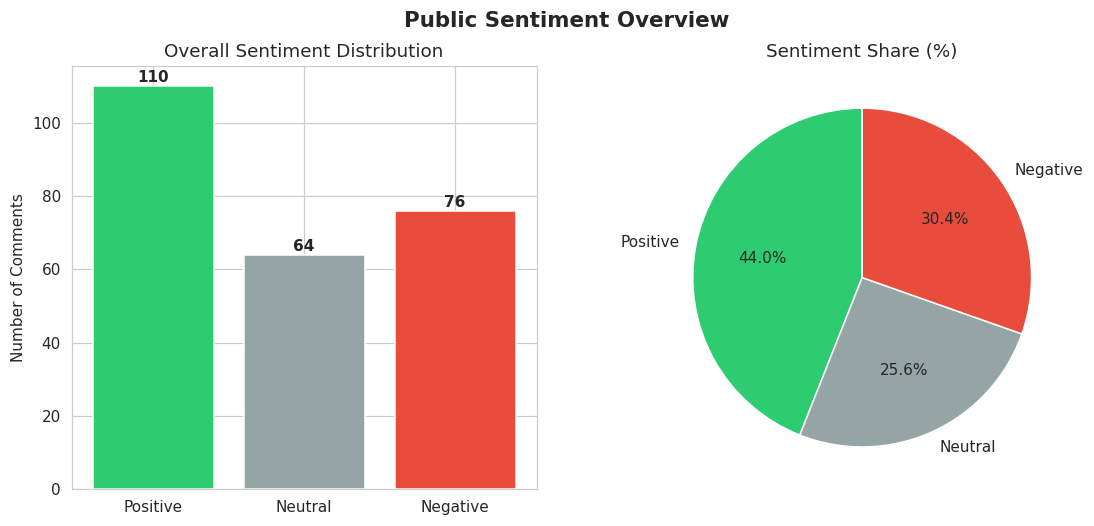

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ["Positive", "Neutral", "Negative"]
colors = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}
counts = df["sentiment"].value_counts().reindex(order)

axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_ylabel("Number of Comments")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[colors[c] for c in counts.index], startangle=90)
axes[1].set_title("Sentiment Share (%)")

plt.suptitle("Public Sentiment Overview", fontsize=14, fontweight="bold")
plt.show()

### 5.2 Sentiment by Platform

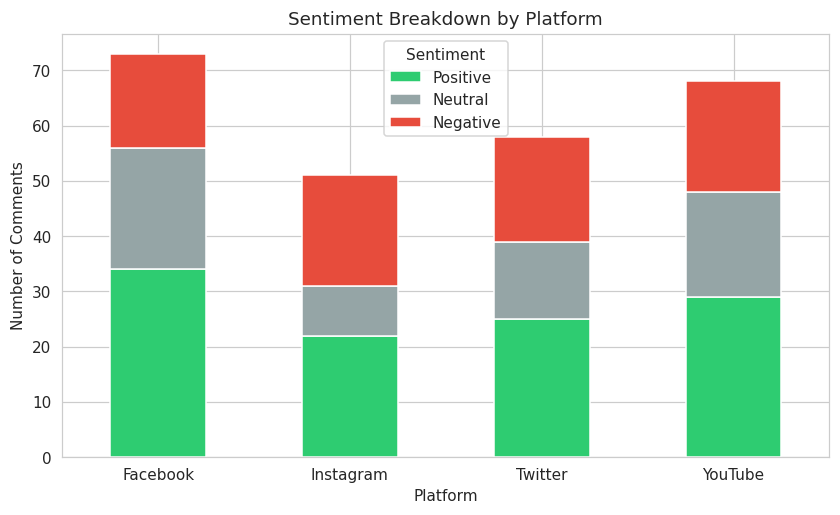

In [8]:
plt.figure(figsize=(9, 5))
cross = pd.crosstab(df["platform"], df["sentiment"])
cross = cross[["Positive", "Neutral", "Negative"]]
cross.plot(kind="bar", stacked=True, color=["#2ecc71", "#95a5a6", "#e74c3c"], ax=plt.gca())
plt.title("Sentiment Breakdown by Platform")
plt.ylabel("Number of Comments")
plt.xlabel("Platform")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.show()

### 5.3 Sentiment Trend Over Time

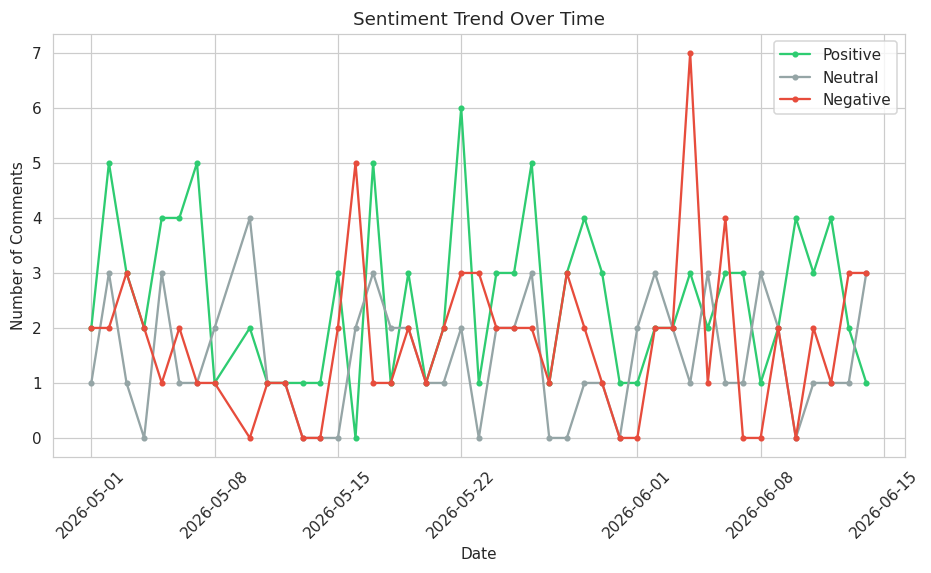

In [9]:
plt.figure(figsize=(10, 5))
daily = df.copy()
daily["date"] = daily["timestamp"].dt.date
trend = daily.groupby(["date", "sentiment"]).size().unstack(fill_value=0)
for col, color in zip(["Positive", "Neutral", "Negative"], ["#2ecc71", "#95a5a6", "#e74c3c"]):
    if col in trend.columns:
        plt.plot(trend.index, trend[col], label=col, color=color, marker="o", markersize=3)
plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.legend()
plt.show()

### 5.4 Top Trending Hashtags

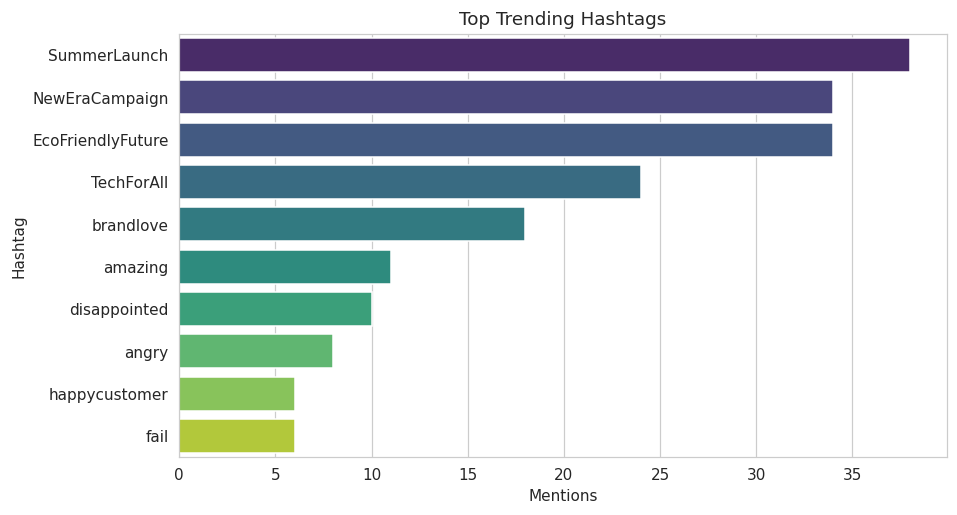

In [10]:
tags, tag_counts = zip(*trending_tags)
plt.figure(figsize=(9, 5))
sns.barplot(x=list(tag_counts), y=list(tags), hue=list(tags), palette="viridis", legend=False)
plt.title("Top Trending Hashtags")
plt.xlabel("Mentions")
plt.ylabel("Hashtag")
plt.show()

### 5.5 Most Frequent Words

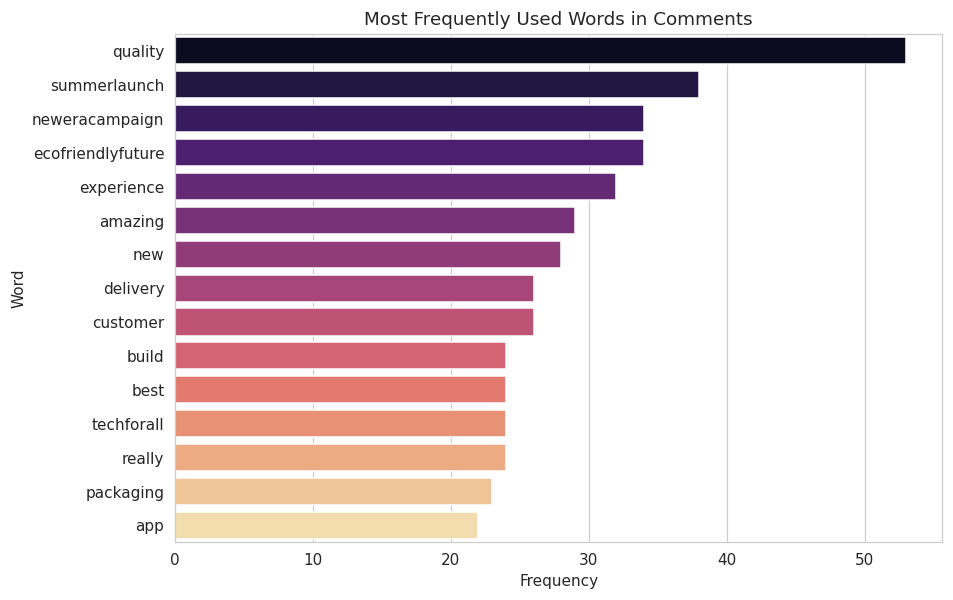

In [11]:
words, word_freqs = zip(*trending_words)
plt.figure(figsize=(9, 6))
sns.barplot(x=list(word_freqs), y=list(words), hue=list(words), palette="magma", legend=False)
plt.title("Most Frequently Used Words in Comments")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

### 5.6 Word-Cloud-Style View

A dependency-free "word cloud" built with matplotlib only (font size scaled by
frequency, random placement) — used since the `wordcloud` package isn't available
in this environment; swap in `from wordcloud import WordCloud` if it's installed
in yours.

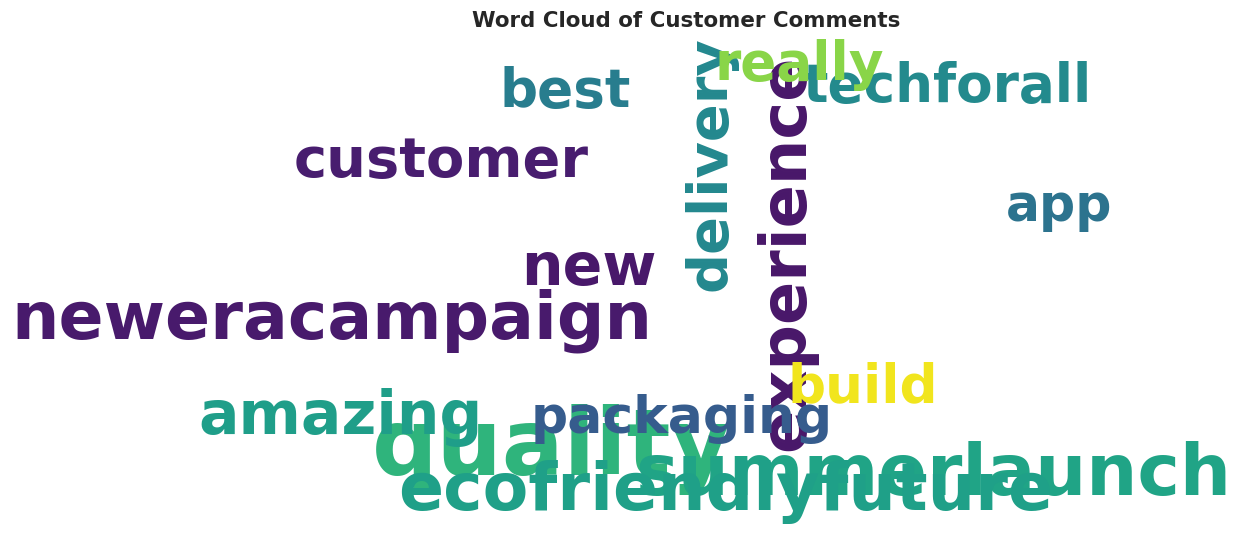

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
max_count = max(c for _, c in trending_words)
rng = random.Random(7)

placed = []
for word, count in trending_words:
    size = 14 + (count / max_count) * 46
    for _ in range(30):
        x, y = rng.uniform(0.05, 0.95), rng.uniform(0.05, 0.95)
        if all((x - px) ** 2 + (y - py) ** 2 > 0.02 for px, py in placed):
            placed.append((x, y))
            break
    else:
        x, y = rng.uniform(0.05, 0.95), rng.uniform(0.05, 0.95)
    color = plt.cm.viridis(rng.random())
    rotation = rng.choice([0, 0, 0, 90])
    ax.text(x, y, word, fontsize=size, color=color, ha="center", va="center",
            rotation=rotation, fontweight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Word Cloud of Customer Comments", fontsize=14, fontweight="bold")
plt.show()

## Summary Report

In [13]:
total = len(df)
pos_pct = (df["sentiment"] == "Positive").mean() * 100
neg_pct = (df["sentiment"] == "Negative").mean() * 100
neu_pct = (df["sentiment"] == "Neutral").mean() * 100

print("SOCIAL MEDIA COMMENT ANALYSIS - SUMMARY REPORT")
print("=" * 50)
print(f"Total comments analyzed : {total}")
print(f"Positive sentiment       : {pos_pct:.1f}%")
print(f"Neutral sentiment        : {neu_pct:.1f}%")
print(f"Negative sentiment       : {neg_pct:.1f}%")
print()
print("Top trending hashtags    :", [t for t, _ in trending_tags[:5]])
print("Top discussed words      :", [w for w, _ in trending_words[:5]])
print()
verdict = "largely positive" if pos_pct > neg_pct else "mixed/negative"
print(f"Overall public perception is {verdict}, with the strongest attention around:")
print(", ".join([w for w, _ in trending_words[:3]]))

SOCIAL MEDIA COMMENT ANALYSIS - SUMMARY REPORT
Total comments analyzed : 250
Positive sentiment       : 44.0%
Neutral sentiment        : 25.6%
Negative sentiment       : 30.4%

Top trending hashtags    : ['SummerLaunch', 'NewEraCampaign', 'EcoFriendlyFuture', 'TechForAll', 'brandlove']
Top discussed words      : ['quality', 'summerlaunch', 'neweracampaign', 'ecofriendlyfuture', 'experience']

Overall public perception is largely positive, with the strongest attention around:
quality, summerlaunch, neweracampaign


## Conclusion

This pipeline demonstrates a complete, end-to-end NLP workflow for social media
comment analysis — from raw comment collection through cleaning, sentiment
classification, topic discovery, and visualization. The same functions can be pointed
at a real exported dataset (Twitter/X, Instagram, Facebook, YouTube) by replacing the
`generate_social_media_dataset()` call with a `pd.read_csv(...)` of real data; every
downstream step (cleaning, sentiment, topics, charts) works unchanged.